In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('preprocess.csv')

In [3]:
df.shape

(283726, 31)

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# EDA
## Univariate analysis
### Class

In [5]:
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


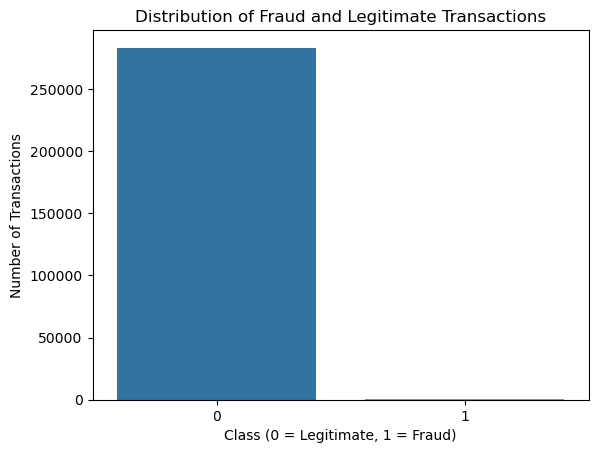

In [6]:
sns.countplot(data=df, x="Class")
plt.title("Distribution of Fraud and Legitimate Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

### Amount 

In [7]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

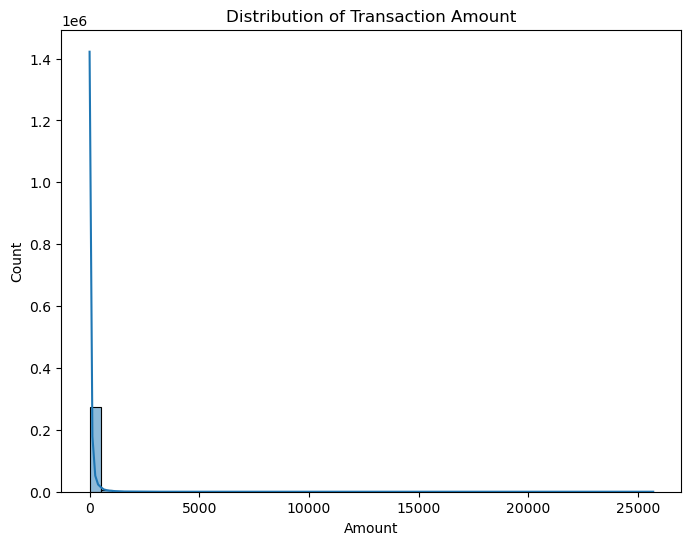

In [8]:
plt.figure(figsize=(8,6))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.show()

In [9]:
print("Amount skewness:", df["Amount"].skew())

Amount skewness: 16.978803370060476


In [10]:
df["log_amount"] = np.log1p(df["Amount"])

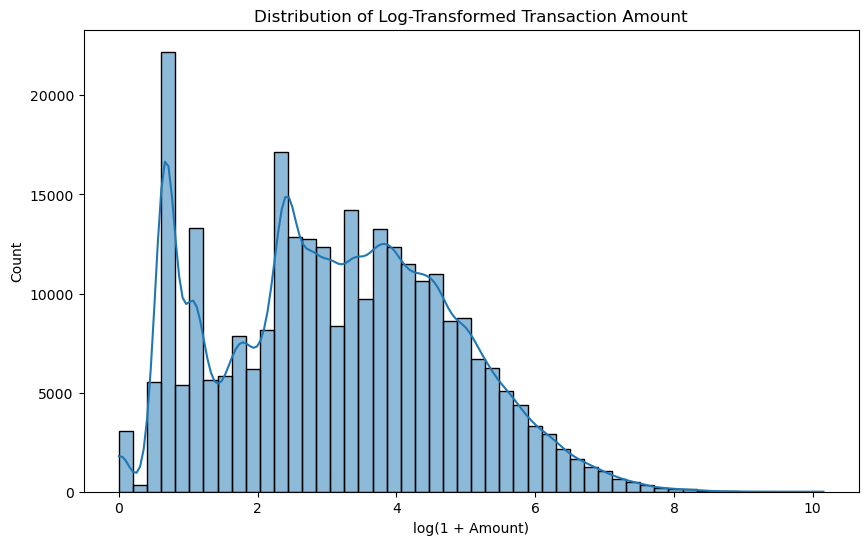

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["log_amount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Transaction Amount")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Count")

plt.show()

In [12]:
print("Original skewness:",
      df["Amount"].skew())

print("Log-transformed skewness:",
      df["log_amount"].skew())

Original skewness: 16.978803370060476
Log-transformed skewness: 0.16141018223366638


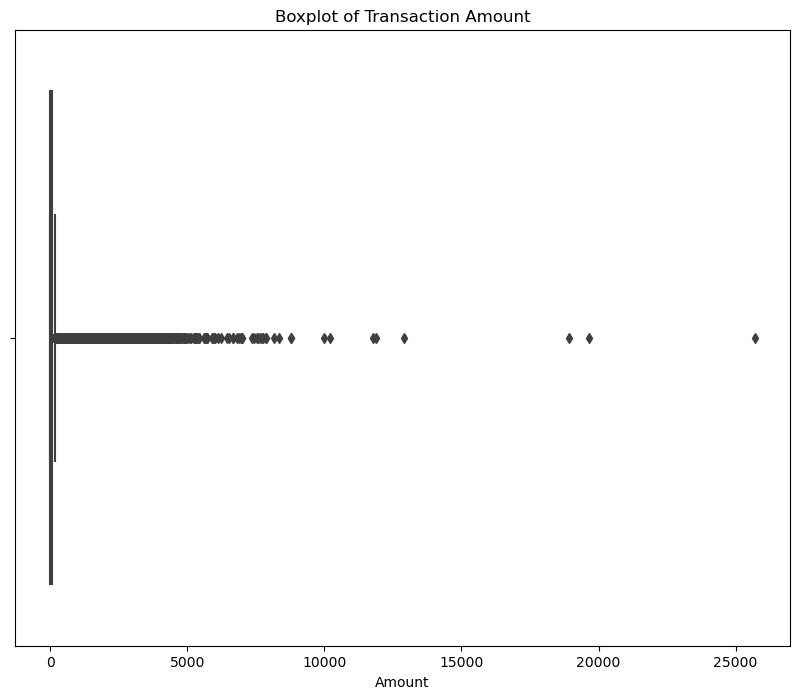

In [13]:
plt.figure(figsize=(10,8))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot of Transaction Amount")
plt.show()

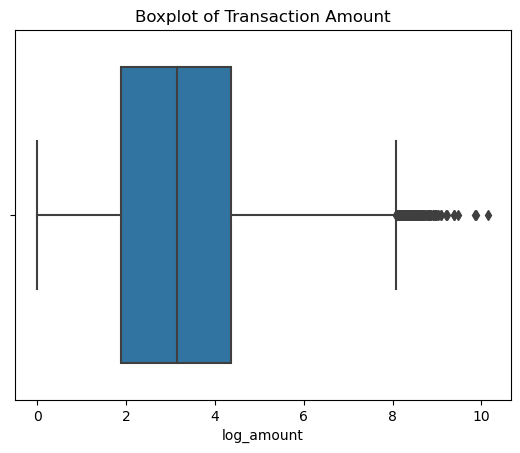

In [14]:
sns.boxplot(x=df["log_amount"])
plt.title("Boxplot of Transaction Amount")
plt.show()

### Time

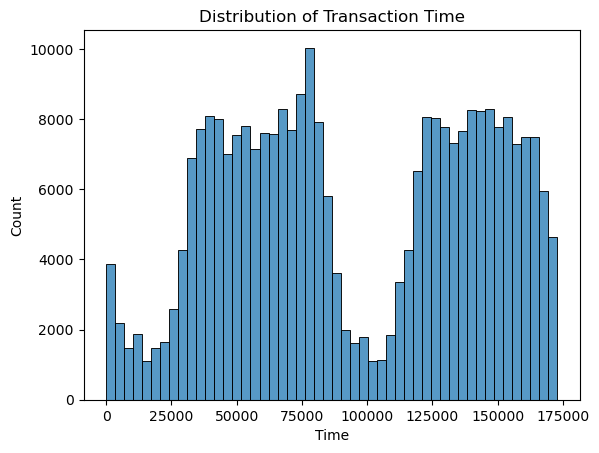

In [15]:
sns.histplot(df["Time"], bins=50)
plt.title("Distribution of Transaction Time")
plt.show()

In [16]:
df["Hour"] = (df["Time"] // 3600) % 24

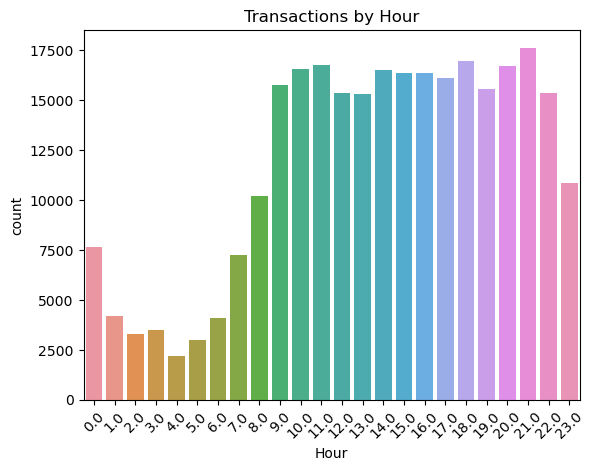

In [17]:
sns.countplot(data=df, x="Hour")
plt.title("Transactions by Hour")
plt.xticks(rotation=45)
plt.show()

### V1-V28

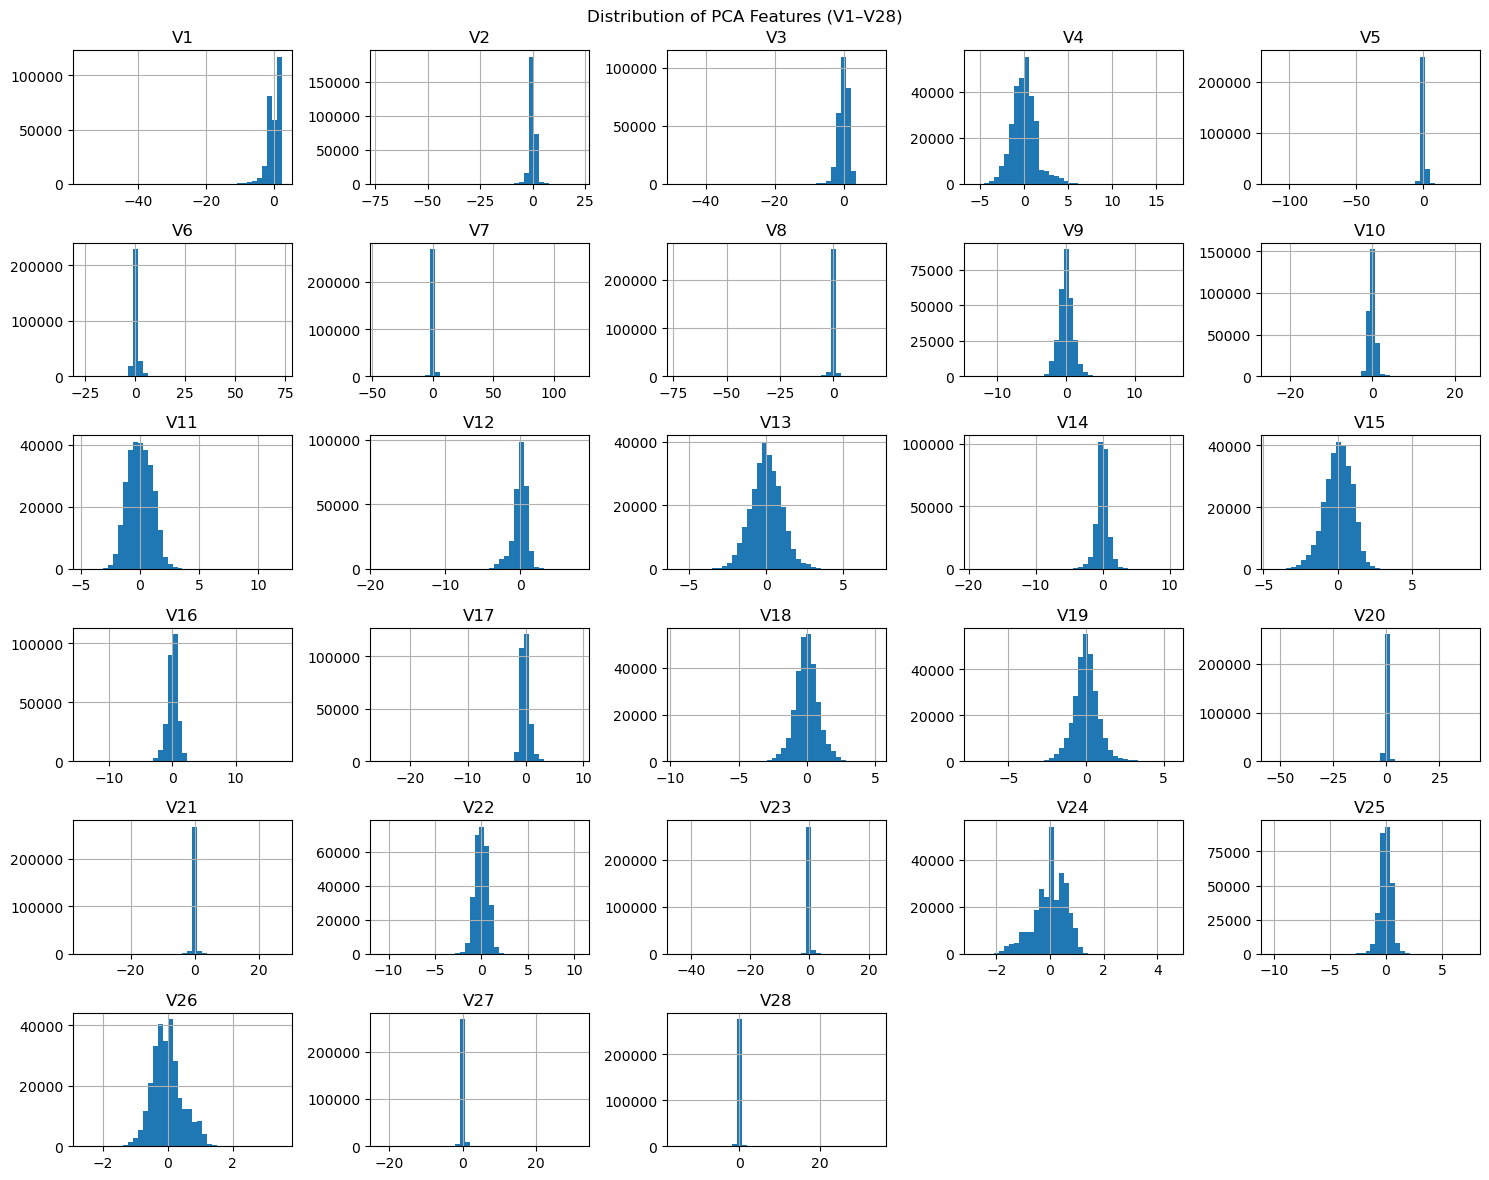

In [18]:
V_columns = [f"V{i}" for i in range(1, 29)]
df[V_columns].hist(bins=40,figsize=(15, 12))

plt.suptitle("Distribution of PCA Features (V1–V28)")
plt.tight_layout()
plt.show()

In [19]:
skewness = df[V_columns].skew().sort_values()

print(skewness)

V8     -8.310970
V23    -5.867221
V2     -4.695162
V17    -3.690497
V1     -3.273271
V5     -2.414079
V12    -2.199008
V3     -2.151984
V20    -2.043121
V14    -1.918804
V16    -1.051161
V27    -0.753804
V24    -0.552129
V25    -0.415744
V15    -0.309659
V18    -0.248661
V22    -0.182330
V13     0.064293
V19     0.108312
V11     0.344074
V9      0.537663
V26     0.580292
V4      0.671504
V10     1.252967
V6      1.829880
V21     2.820033
V7      2.890271
V28    11.555115
dtype: float64


In [20]:
df[V_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995
V10,283726.0,-0.001441,1.076407,-24.588262,-0.535578,-0.093237,0.453619,23.745136


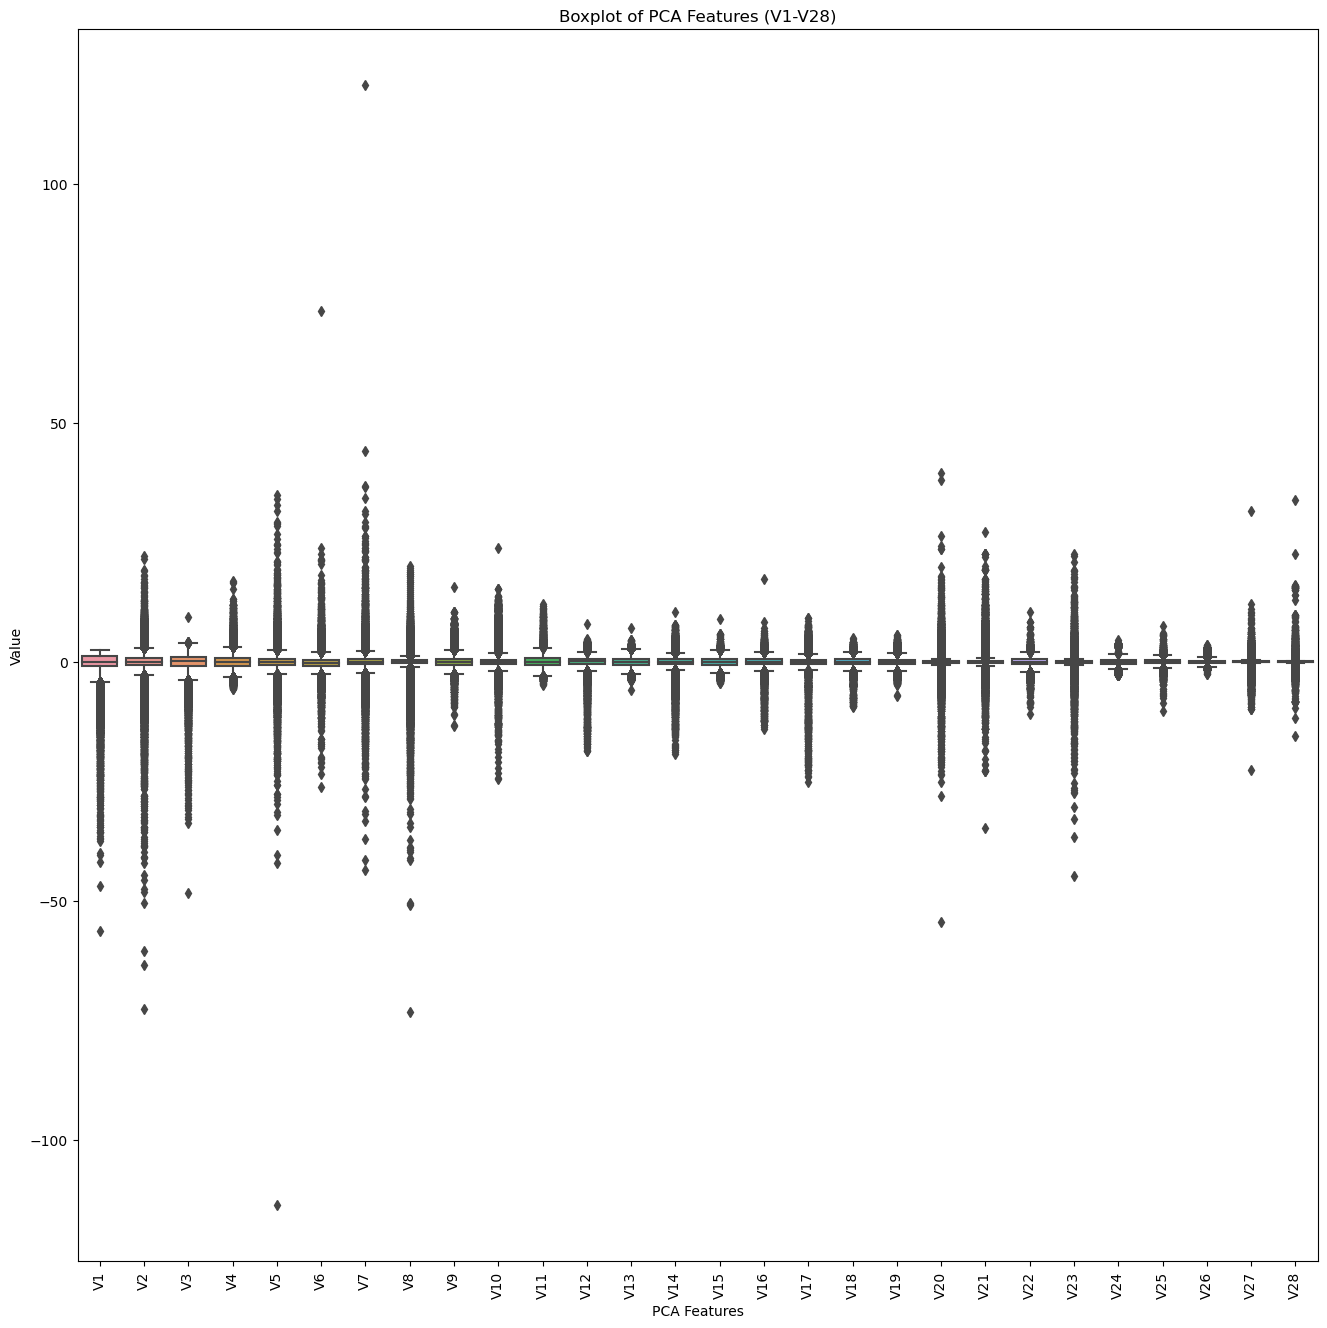

In [21]:
plt.figure(figsize=(16, 16))

sns.boxplot(data=df[V_columns])

plt.title("Boxplot of PCA Features (V1-V28)")
plt.xlabel("PCA Features")
plt.ylabel("Value")
plt.xticks(rotation=90)

plt.show()

### univariate comparison

In [22]:
df.groupby("Class")[["Amount"] + V_columns].mean().T

Class,0,1
Amount,88.413575,123.871860
V1,0.013439,-4.498280
V2,-0.009829,3.405965
V3,0.012853,-6.729599
V4,-0.010440,4.472591
V5,0.006769,-2.957197
V6,0.001251,-1.432518
V7,0.010447,-5.175912
V8,-0.002448,0.953255
V9,0.002613,-2.522124


In [23]:
df.groupby("Class")[["Amount"] + V_columns].median().T

Class,0,1
Amount,22.000000,9.820000
V1,0.022562,-2.271755
V2,0.062561,2.617105
V3,0.182247,-4.875397
V4,-0.024500,4.100098
V5,-0.052807,-1.372245
V6,-0.274172,-1.420468
V7,0.041664,-2.902079
V8,0.021633,0.617738
V9,-0.051368,-2.099049


## Bivariate Analysis
### Amount vs Class

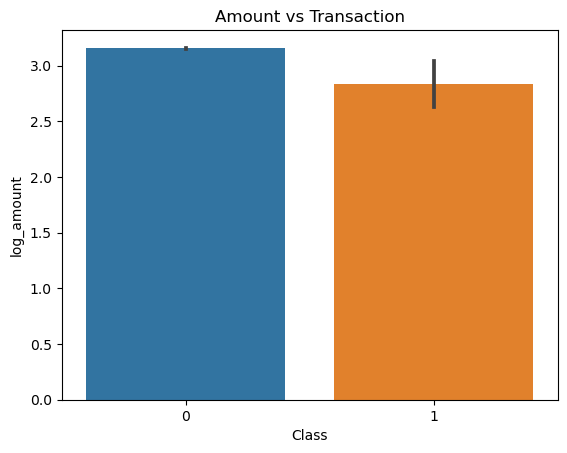

In [24]:
sns.barplot(data=df,x=df['Class'],y=df['log_amount'])
plt.title('Amount vs Transaction')
plt.show()

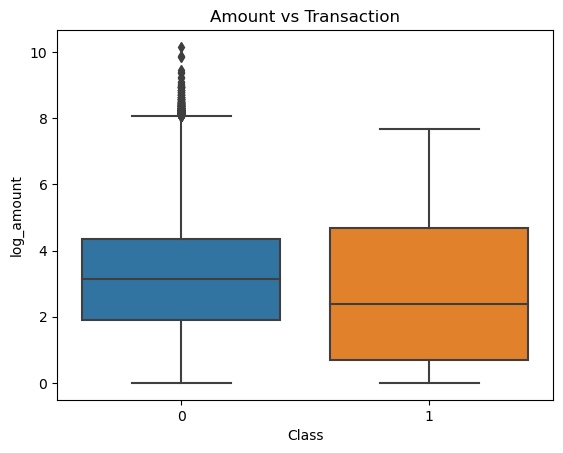

In [25]:
sns.boxplot(data=df,x=df['Class'],y=df['log_amount'])
plt.title('Amount vs Transaction')
plt.show()

In [26]:
amount_stats = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

print(amount_stats)

        count        mean  median         std  min       max
Class                                                       
0      283253   88.413575   22.00  250.379023  0.0  25691.16
1         473  123.871860    9.82  260.211041  0.0   2125.87


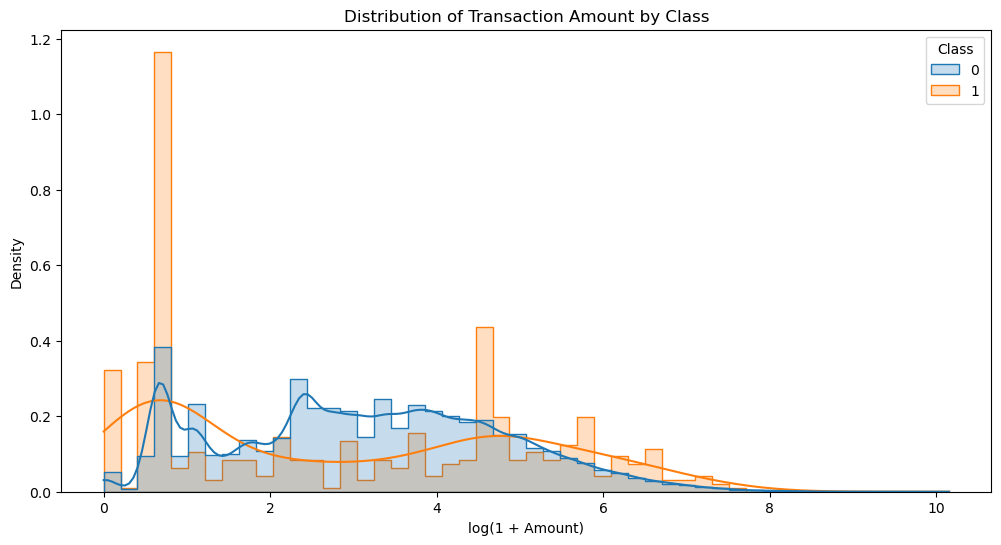

In [27]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="log_amount",
    hue="Class",
    bins=50,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribution of Transaction Amount by Class")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Density")

plt.show()

### Time vs Class

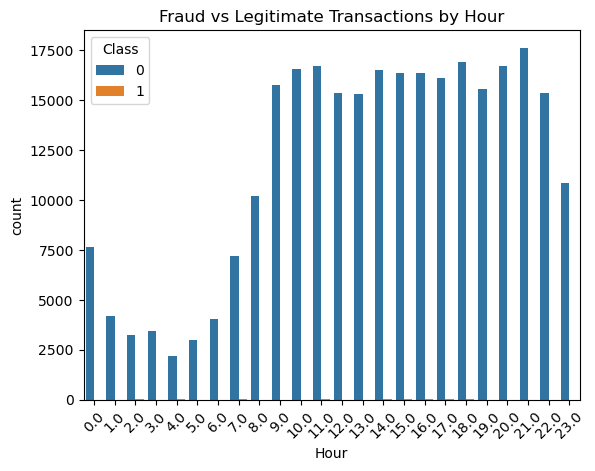

In [28]:
sns.countplot(data=df, x="Hour", hue="Class")
plt.title("Fraud vs Legitimate Transactions by Hour")
plt.xticks(rotation = 45)
plt.show()

In [29]:
hour_class = pd.crosstab(df["Hour"],df["Class"],normalize="index" ) * 100

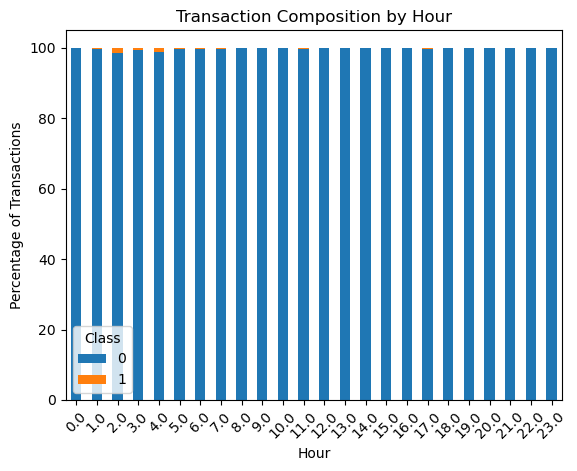

In [30]:
hour_class.plot(kind='bar',stacked=True)

plt.title("Transaction Composition by Hour")
plt.xlabel("Hour")
plt.ylabel("Percentage of Transactions")
plt.xticks(rotation=45)
plt.show()

### V1-V28 vs Class

In [31]:
stats = []

for feature in V_columns:
    legit = df.loc[df["Class"] == 0, feature]
    fraud = df.loc[df["Class"] == 1, feature]

    pooled_std = np.sqrt(
        (legit.var() + fraud.var()) / 2)

    effect = (fraud.mean() - legit.mean()) / pooled_std

    stats.append({"Feature": feature,"Effect_Size": effect})

effect_df = pd.DataFrame(stats)

effect_df["Abs_Effect"] = effect_df["Effect_Size"].abs()

effect_df = effect_df.sort_values("Abs_Effect",ascending=False)

print(effect_df)

   Feature  Effect_Size  Abs_Effect
13     V14    -2.228136    2.228136
3       V4     1.984959    1.984959
11     V12    -1.847619    1.847619
10     V11     1.844141    1.844141
9      V10    -1.602536    1.602536
15     V16    -1.444884    1.444884
2       V3    -1.350277    1.350277
8       V9    -1.325343    1.325343
16     V17    -1.306905    1.306905
1       V2     1.089375    1.089375
6       V7    -1.054071    1.054071
17     V18    -1.013591    1.013591
5       V6    -0.934186    0.934186
0       V1    -0.929074    0.929074
4       V5    -0.769092    0.769092
18     V19     0.546396    0.546396
19     V20     0.382049    0.382049
7       V8     0.236928    0.236928
20     V21     0.234268    0.234268
26     V27     0.229925    0.229925
23     V24    -0.189935    0.189935
27     V28     0.175965    0.175965
25     V26     0.106615    0.106615
12     V13    -0.090289    0.090289
21     V22     0.088612    0.088612
22     V23    -0.083931    0.083931
14     V15    -0.075327    0

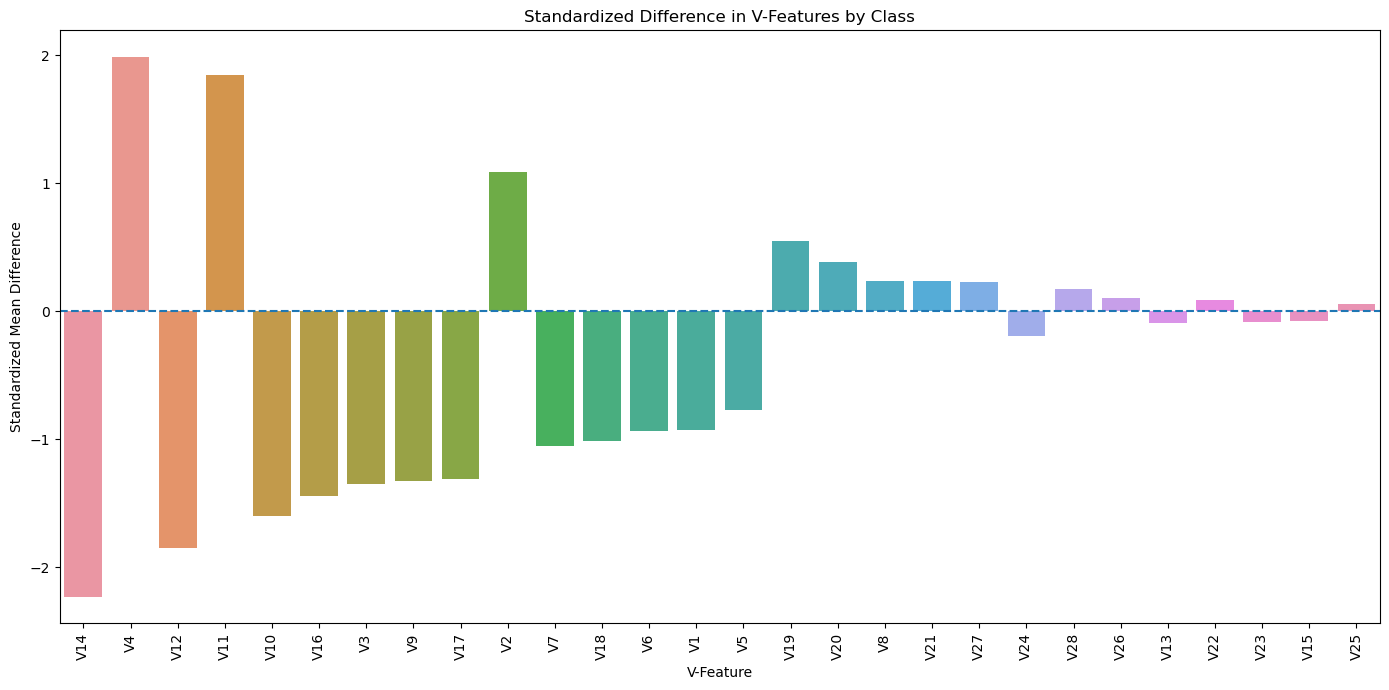

In [32]:
plt.figure(figsize=(14, 7))

sns.barplot(data=effect_df,x="Feature",y="Effect_Size")

plt.axhline(0, linestyle="--")

plt.title("Standardized Difference in V-Features by Class")
plt.xlabel("V-Feature")
plt.ylabel("Standardized Mean Difference")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Multivariate Analysis


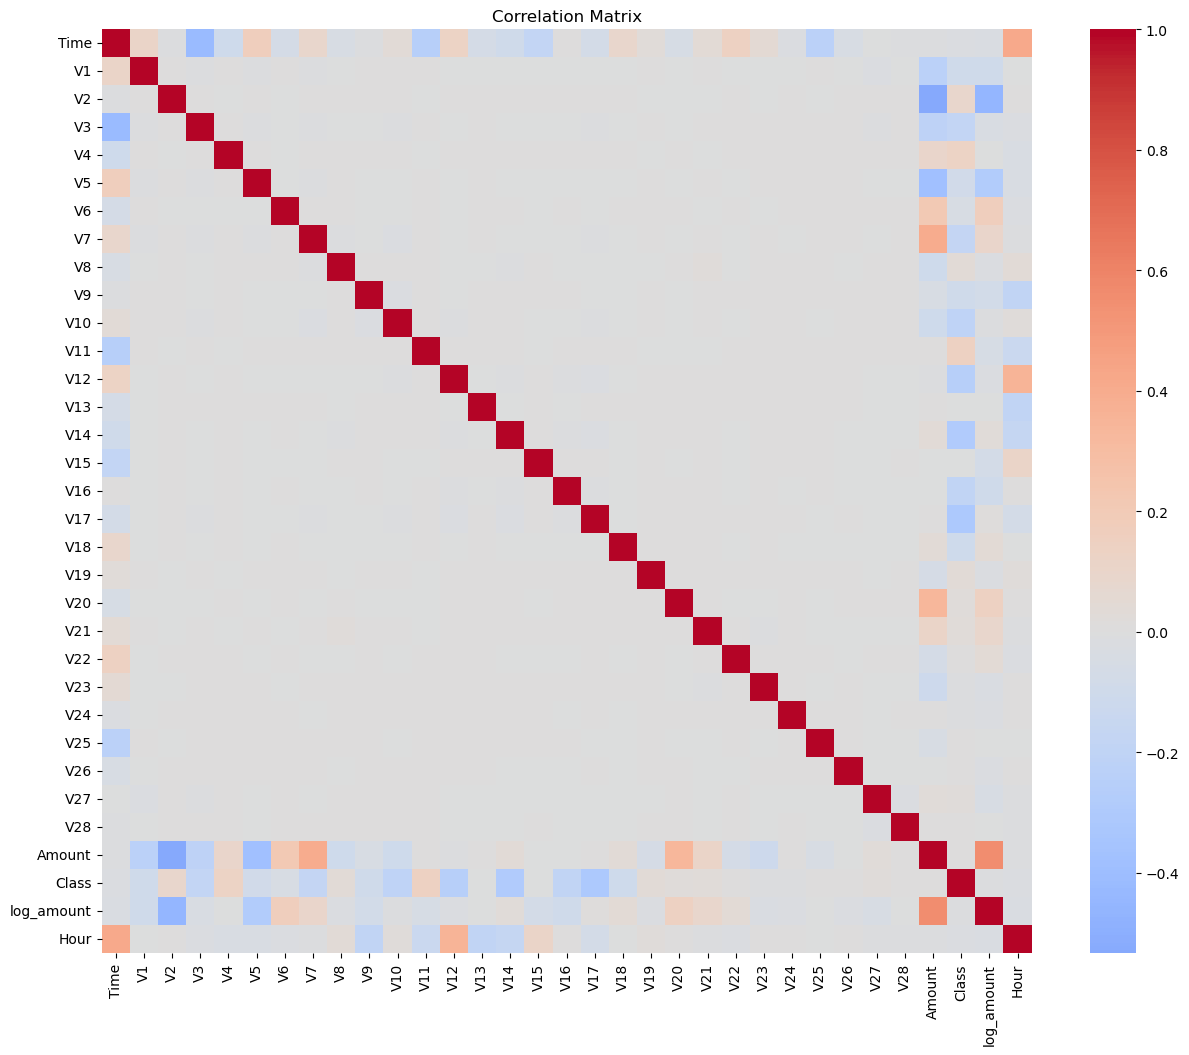

In [40]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15, 12))

sns.heatmap(corr,cmap="coolwarm",center=0)

plt.title("Correlation Matrix")
plt.show()

In [34]:
plt.figure(figsize=(12, 8))

corr_class = (df.corr(numeric_only=True)["Class"].sort_values(ascending=False))

print(corr_class)

Class         1.000000
V11           0.149067
V4            0.129326
V2            0.084624
V19           0.033631
V8            0.033068
V21           0.026357
V27           0.021892
V20           0.021486
V28           0.009682
Amount        0.005777
V22           0.004887
V26           0.004265
V25           0.003202
V15          -0.003300
V13          -0.003897
V23          -0.006333
V24          -0.007210
log_amount   -0.007798
Time         -0.012359
Hour         -0.016740
V6           -0.043915
V5           -0.087812
V9           -0.094021
V1           -0.094486
V18          -0.105340
V7           -0.172347
V3           -0.182322
V16          -0.187186
V10          -0.206971
V12          -0.250711
V14          -0.293375
V17          -0.313498
Name: Class, dtype: float64


<Figure size 1200x800 with 0 Axes>

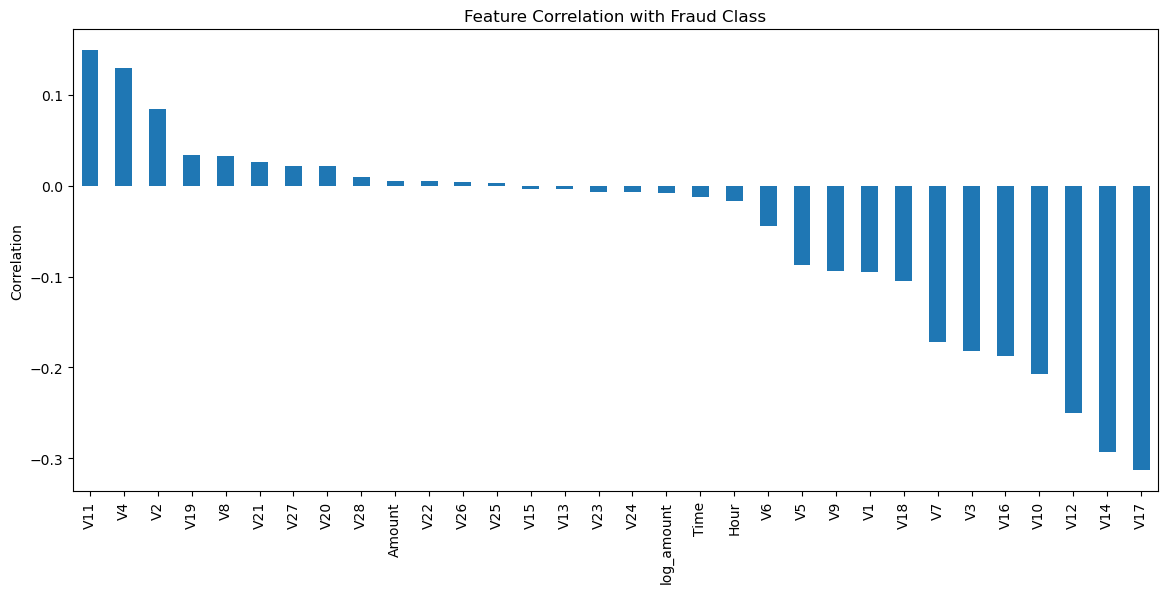

In [35]:
corr_class.drop("Class").plot(kind="bar",figsize=(14, 6))

plt.title("Feature Correlation with Fraud Class")
plt.ylabel("Correlation")
plt.show()

# PCA Visulaization for EDA


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [f"V{i}" for i in range(1, 29)] + ["Amount"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca,columns=["PC1", "PC2"])

pca_df["Class"] = df["Class"].values

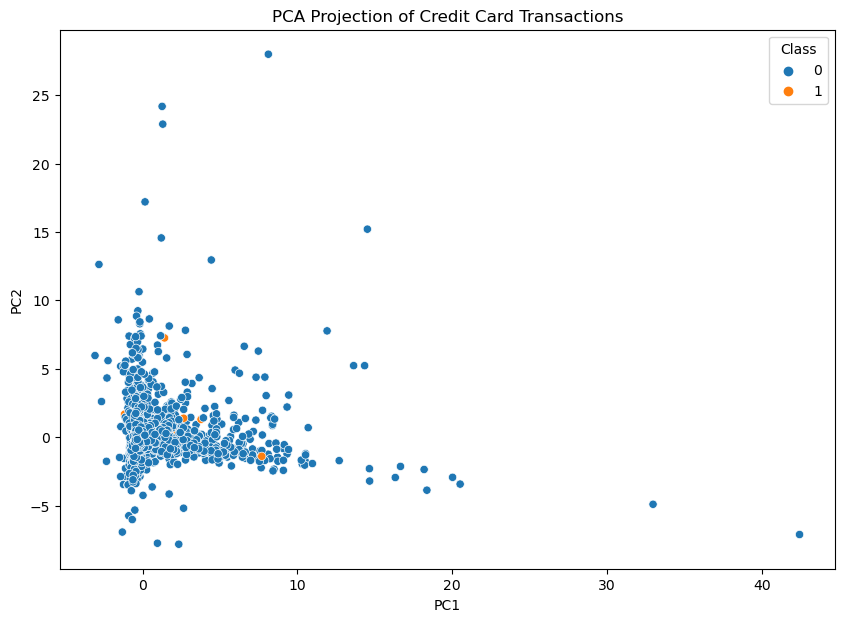

In [37]:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=pca_df.sample(10000, random_state=42),x="PC1",y="PC2",hue="Class")

plt.title("PCA Projection of Credit Card Transactions")
plt.show()

In [39]:
df.to_csv('eda.csv',index=False)

# Report 
### Univariate Analysis
#### Class
- are highly imbalance Class (0 = Legitimate ----> 283253 , 1 = Fraud----> 473)
#### Amount
- The distribution of amounts is highly right-skewed. 
- Therefore, a log1p transformation was considered to compress extreme values and produce a more balanced feature distribution.
#### Time
- Time represents seconds elapsed since the first transaction, not a normal clock time.
- Convert it into hour
- The No# transaction rapidly increase after 8th hour
#### V1-V28
- The univariate analysis of the anonymized PCA features (V1–V28) shows that most features are concentrated around zero, while their ranges, spreads, and distribution shapes vary considerably.
- Several features exhibit approximately symmetric distributions, whereas others display skewness and extreme values.
- Since V1–V28 are already PCA-derived anonymized components, individual features were not assigned domain-specific interpretations or subjected to arbitrary transformations.
- Their statistical distributions were examined to guide subsequent preprocessing and modeling decisions.
#### univariate comparison
- The mean value of mount for Legitimate transaction----> 88.413575 and for Fraud---> 123.871860
- The mean value of mount for Legitimate transaction----> 22.000000 and for Fraud---> 9.820000
- For Legitimate and Fraud transaction the values of V1-V28  is completly inverse
### Bivariate Analysis
#### Amount vs Class
- The analysis shows that transaction amounts have different distributions for legitimate and fraudulent transactions.
- Since the original Amount variable is highly right-skewed, a log1p transformation was used for visualization to reduce the influence of extreme values.
- Boxplots and distribution plots were used to compare the two classes, while summary statistics were used to examine differences in their central tendency and dispersion.
#### Hourly vs Transaction
- The distribution of transactions across hours was analyzed separately for legitimate and fraudulent transactions.
- Due to the severe class imbalance, a conventional count plot makes fraudulent transactions difficult to visualize. Therefore, a logarithmic count plot and a normalized 100% stacked bar chart were used to compare the two classes while preserving the information contained in both categories.
#### V-Features vs Class
- The standardized mean difference analysis reveals substantial differences between fraudulent and legitimate transactions for several PCA-derived features.
- V14 exhibits the largest negative standardized difference, indicating that its mean value is considerably lower for fraudulent transactions.
- In contrast, V4 and V11 show large positive standardized differences, indicating higher mean values for fraudulent transactions. 
- V12, V10, V16, V3, V9, and V17 also show substantial negative differences. Features such as V13, V15, V22, V23, and V25 are close to zero, indicating relatively small differences in their class-specific means.
- These results suggest that several anonymized PCA features contain strong discriminatory information and warrant further investigation during model development.
### Multivariate Analysis
- The correlation heatmap shows relatively weak linear correlations among the PCA-derived V1-V28 features, which is consistent with the properties of PCA-transformed components.
- standardized mean difference shows how separated the class-specific means are